In [1]:
from ultralytics import RTDETR

model = RTDETR("rtdetr-l.pt")
model.info()

results = model.train(data='./Scananagrams.yolov8', epochs = 50, imgsz=640)

WARNING Ultralytics settings updated to the latest schema. Existing values were preserved where possible. 
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\isaac\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
rt-detr-l summary: 449 layers, 32,970,476 parameters, 0 gradients, 110.2 GFLOPs
Ultralytics 8.4.121  Python-3.11.5 torch-2.13.0+cpu CPU (13th Gen Intel Core i7-13700H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./Scananagrams.yolov8, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None,


image 1/1 c:\IzzysWorkshop\PeelBack\TestImage.jpg: 640x640 16 Tiles, 496.4ms
Speed: 4.2ms preprocess, 496.4ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)


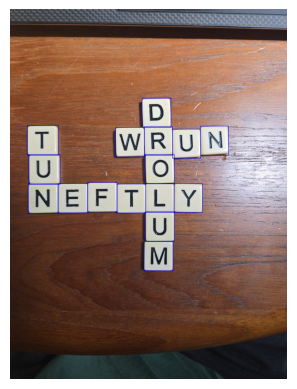

array([[     521.73,      1884.6,      841.37,        2202],
       [       1452,      1269.8,      1759.6,      1578.4],
       [     189.66,      1255.5,      524.71,      1578.2],
       [     198.02,      1888.6,      519.73,      2208.6],
       [     2061.1,      1262.7,      2363.6,      1580.2],
       [     1758.5,      1295.3,      2062.7,      1610.5],
       [     1159.3,      1889.4,      1468.3,      2202.7],
       [     205.35,      1571.6,      541.09,      1892.9],
       [     1451.3,      2508.3,      1763.6,      2828.8],
       [     839.84,      1871.7,        1157,        2191],
       [     1429.7,       960.3,      1741.4,      1277.6],
       [     1776.6,      1885.5,      2082.8,      2196.5],
       [     1465.1,      2190.4,      1777.2,      2512.8],
       [     1468.6,      1883.6,      1775.7,      2195.4],
       [     1143.5,      1277.1,      1454.7,      1597.5],
       [     1465.2,      1571.5,      1777.3,      1887.4]], dtype=float32)

In [6]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import RTDETR


imagePath = 'TestImage.jpg'

image = cv2.imread('TestImage.jpg', cv2.IMREAD_COLOR_RGB)
# image = cv2.resize(image,(640,640))

myModel = RTDETR('runs/detect/train/weights/best.pt')
result = myModel.predict(imagePath)

boxes = result[0].boxes.xyxy.cpu().numpy()

for box in boxes:
    x1,y1,x2,y2 = map(int,box)
    cv2.rectangle(image, (x1,y1),(x2,y2), (0,0,250),3)

plt.imshow(image)
plt.axis('off')
plt.show()
boxes